<a href="https://colab.research.google.com/github/rohanwillcode/BMW-Car-Price-Prediction-Model-/blob/main/BMW_PRICE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [465]:
df= pd.read_csv('bmw.csv')

In [466]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [467]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [468]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [469]:
df['fuelType'].value_counts()

,count
fuelType,
Diesel,7027
Petrol,3417
Hybrid,298
Other,36
Electric,3


In [470]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


<Axes: xlabel='mileage', ylabel='Count'>

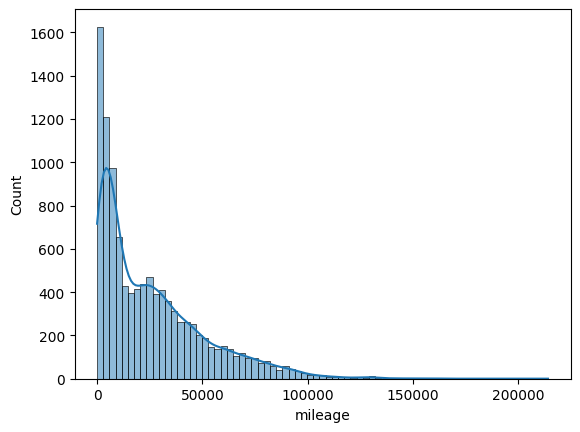

In [471]:
sns.histplot(x=df['mileage'],kde=True)

In [472]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [473]:
df.duplicated().sum()

np.int64(117)

In [474]:
df.drop_duplicates(inplace=True)

In [475]:
df.duplicated().sum()

np.int64(0)

In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10664 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10664 non-null  object 
 1   year          10664 non-null  int64  
 2   price         10664 non-null  int64  
 3   transmission  10664 non-null  object 
 4   mileage       10664 non-null  int64  
 5   fuelType      10664 non-null  object 
 6   tax           10664 non-null  int64  
 7   mpg           10664 non-null  float64
 8   engineSize    10664 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 833.1+ KB


In [477]:
df.shape

(10664, 9)

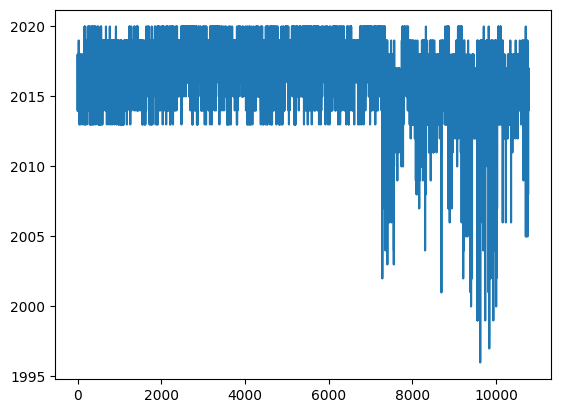

In [478]:
plt.plot(df['year'])

Text(0.5, 1.0, 'Price Distribution')

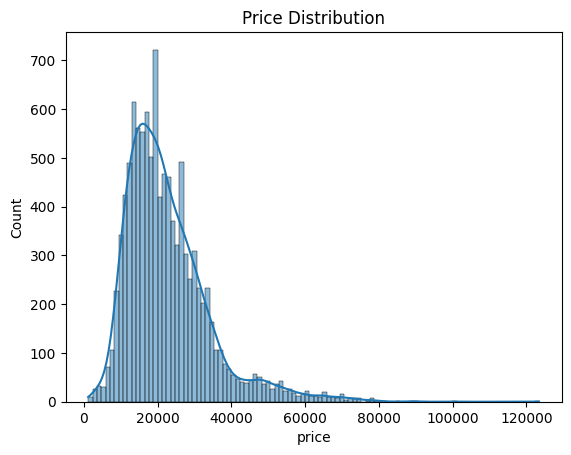

In [479]:
sns.histplot(df['price'],kde=True)
plt.title('Price Distribution')

In [480]:
X= df.drop(columns= ['price'])
y= df['price']
X,y

(           model  year transmission  mileage fuelType  tax   mpg  engineSize
 0       5 Series  2014    Automatic    67068   Diesel  125  57.6         2.0
 1       6 Series  2018    Automatic    14827   Petrol  145  42.8         2.0
 2       5 Series  2016    Automatic    62794   Diesel  160  51.4         3.0
 3       1 Series  2017    Automatic    26676   Diesel  145  72.4         1.5
 4       7 Series  2014    Automatic    39554   Diesel  160  50.4         3.0
 ...          ...   ...          ...      ...      ...  ...   ...         ...
 10776         X3  2016    Automatic    40818   Diesel  150  54.3         2.0
 10777   5 Series  2016    Automatic    42947   Diesel  125  60.1         2.0
 10778   3 Series  2017       Manual    25468   Petrol  200  42.8         2.0
 10779   1 Series  2014    Automatic    45000   Diesel   30  64.2         2.0
 10780         X1  2017    Automatic    59432   Diesel  125  57.6         2.0
 
 [10664 rows x 8 columns],
 0        11200
 1        27000
 2 

In [481]:
corr= df.corr(numeric_only=True)

In [482]:
y= pd.DataFrame(y)
y

,price
0,11200
1,27000
2,16000
3,12750
4,14500
...,...
10776,19000
10777,14600
10778,13100
10779,9930


<Axes: >

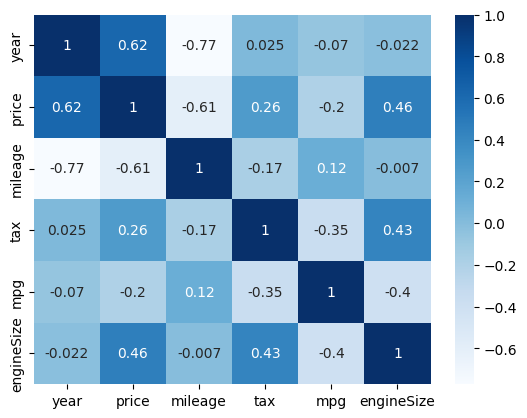

In [483]:
sns.heatmap(corr,cmap='Blues',annot=True)

In [484]:
df['year'].value_counts()

,count
year,
2019,3396
2016,1877
2017,1718
2015,921
2018,846
2020,722
2014,498
2013,355
2012,119


In [485]:
X.corrwith(y['price'],numeric_only=True)

,0
year,0.623754
mileage,-0.605473
tax,0.264178
mpg,-0.203986
engineSize,0.461750


In [486]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,Automatic,39554,Diesel,160,50.4,3.0


In [487]:
X['fuelType'].value_counts()

,count
fuelType,
Diesel,6988
Petrol,3340
Hybrid,297
Other,36
Electric,3


In [488]:
X['transmission'].value_counts()

,count
transmission,
Semi-Auto,4637
Automatic,3542
Manual,2485


In [489]:
X['model'].value_counts()

,count
model,
3 Series,2434
1 Series,1962
2 Series,1188
5 Series,1051
4 Series,986
X1,797
X3,550
X5,464
X2,261


In [490]:
from sklearn.preprocessing import MinMaxScaler

mms= MinMaxScaler()



In [491]:
df[df['engineSize']<0.00].shape

(0, 9)

In [492]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10664.000000,10664.000000,10664.000000,10664.000000,10664.000000,10664.000000
mean,2017.062828,22692.888691,25710.978995,131.597431,56.483121,2.170161
std,2.350668,11434.921030,25146.634940,61.611394,31.465604,0.552556
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14897.000000,5665.750000,135.000000,45.600000,2.000000
50%,2017.000000,20261.500000,18783.000000,145.000000,53.300000,2.000000
75%,2019.000000,27890.000000,38436.500000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [493]:
np.log1p(df['tax']).describe()

,tax
count,10664.000000
mean,4.628085
std,1.040840
min,0.000000
25%,4.912655
50%,4.983607
75%,4.983607
max,6.364751


#Encoding types

1. Model: One Hot encoding

2. Transmission: One Hot encoding

3. Fuel Type: One Hot encoding

In [494]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.3,random_state= 2)

In [495]:
from math import remainder
from sklearn.preprocessing import OneHotEncoder
# OneHotEncoder(sparse_output= False, drop='first')

In [496]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


preprocessor= ColumnTransformer(
    transformers= [
        ('model',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['model']),
        ('transmission',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['transmission']),
        ('fuelType',OneHotEncoder(sparse_output= False,handle_unknown='ignore'),['fuelType']),
        ('year',MinMaxScaler(),['year']),
        ('mileage',FunctionTransformer(np.log1p,validate=False),['mileage']),
        ('tax',FunctionTransformer(np.log1p,validate=False),['tax']),
        ('mpg',FunctionTransformer(np.log1p,validate=False),['mpg'])

    ]
)




In [497]:
X_train_transformer= preprocessor.fit_transform(X_train)
X_test_transformer= preprocessor.transform(X_test)




In [498]:
X_train_transformer.shape

(7464, 35)

In [499]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()

model.fit(X_train_transformer,y_train)

LinearRegression()

In [500]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score)


X_train_predict= model.predict(X_train_transformer)
X_test_predict= model.predict(X_test_transformer)





In [501]:
mae= mean_absolute_error(y_train,X_train_predict)

r2= r2_score(y_train,X_train_predict)

In [502]:
mae

2718.052163124451

In [503]:
r2

0.8622783326870248

In [504]:
mae_test= mean_absolute_error(y_test,X_test_predict)

r2_test= r2_score(y_test,X_test_predict)

In [505]:
mae_test

2813.740349523571

In [506]:
r2_test

0.857129282381893